In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.inspection import PartialDependenceDisplay
import pickle

In [2]:
#Load the game data
game_data = pd.read_csv("/home/iolson26/Math stuff/Games_Spreadsheets/Compiled DATA REAL.csv")
game_data.head()

,Date,Year,Home_team,Away_Team,Home_winner?,Away_Winner?,Ratio A/T,APG,BKPG,RPG DEF,...,RPG,REB MAR,OPP PPG,PPG,SCR MAR,STPG,Pct (W/L),3FG% OPP,3FG%,TO MAR
0,11-13-2015,2015,Michigan State,Florida Atlantic,True,False,0.77,8.8,0.9,5.43,...,9.0,17.7,-9.9,13.5,23.4,-0.8,58.7,-4.5,9.6,-1.6
1,11-13-2015,2015,Old Dominion,Niagara,True,False,0.71,2.5,0.7,1.14,...,2.3,5.7,-10.4,3.9,14.4,0.6,43.9,-4.2,1.9,4.6
2,11-13-2015,2015,Purdue,N.C. A&T,True,False,0.68,7.0,2.3,4.91,...,5.4,11.8,-10.8,10.1,21.0,-0.9,43.0,-2.5,5.3,-1.5
3,11-13-2015,2015,VCU,Prairie View A&M,True,False,0.67,5.7,1.1,4.29,...,5.2,8.4,-3.2,16.9,20.1,0.9,46.8,3.1,8.0,2.5
4,11-13-2015,2015,Virginia,Morgan State,True,False,0.65,3.6,1.0,0.41,...,-3.0,7.5,-11.6,3.6,15.2,-0.7,49.4,3.2,10.2,-0.3


In [3]:
#Format game data
game_data = game_data.drop(columns=["Date", "Year", "Home_team", "Away_Team", "Away_Winner?"
                                    , "Pct (W/L)", "SCR MAR"
                                    ])
game_data.head()

,Home_winner?,Ratio A/T,APG,BKPG,RPG DEF,FG%,OPP FG%,FT%,RPG OFF,PFPG,OPP RPG,RPG,REB MAR,OPP PPG,PPG,STPG,3FG% OPP,3FG%,TO MAR
0,True,0.77,8.8,0.9,5.43,7.9,-7.6,-0.2,3.65,0.1,-8.7,9.0,17.7,-9.9,13.5,-0.8,-4.5,9.6,-1.6
1,True,0.71,2.5,0.7,1.14,3.9,-2.8,-1.3,1.18,-1.5,-3.5,2.3,5.7,-10.4,3.9,0.6,-4.2,1.9,4.6
2,True,0.68,7.0,2.3,4.91,6.4,-5.3,3.3,0.47,-5.1,-6.4,5.4,11.8,-10.8,10.1,-0.9,-2.5,5.3,-1.5
3,True,0.67,5.7,1.1,4.29,7.1,-1.6,0.6,0.97,-2.7,-3.0,5.2,8.4,-3.2,16.9,0.9,3.1,8.0,2.5
4,True,0.65,3.6,1.0,0.41,9.5,-3.6,6.7,-3.43,-2.4,-10.6,-3.0,7.5,-11.6,3.6,-0.7,3.2,10.2,-0.3


In [4]:
#Split game data into train, test, and validation sets
x, y = game_data.loc[:, (game_data.columns != "Home_winner?")], game_data["Home_winner?"]
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=.2, random_state=42)
xtrain, xval, ytrain, yval = train_test_split(xtrain,ytrain, test_size=.25, random_state=42)

In [5]:
#Black magic that encodes the game data so it can be read by the model
label_encoder = LabelEncoder()
ytrain = label_encoder.fit_transform(ytrain)
yval   = label_encoder.transform(yval)
ytest  = label_encoder.transform(ytest)

In [6]:
#This black magic scales it to be read by the model
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xval = scaler.transform(xval)
xtest = scaler.transform(xtest)

In [95]:
#Creates our random forest

#Hyper Params 
rf_model = RandomForestClassifier(
 n_estimators=1500, 
 criterion='gini', 
 max_depth=15, 
 min_samples_split=10, 
 min_samples_leaf=4, 
 max_features='sqrt', 
 min_impurity_decrease=0.0, 
 bootstrap=True, 
 n_jobs=-1, 
 random_state=42, 
 class_weight="balanced_subsample", 
 ccp_alpha=0.0, 
 max_samples=.6
)

#Train RF on training data
rf_model.fit(xtrain,ytrain)

#Saves the random forest in .pkl file
with open("game_predictor_forest.pkl", "wb") as f:
    pickle.dump({
        "model": rf_model,
        "scaler": scaler,
        "feature_names": x.columns.tolist() 
}, open("game_predictor_forest.pkl", "wb"))

In [96]:
#Make a prediciton
ypred = rf_model.predict(xval)

In [97]:
#Finds test accuracy as well as makes more in deapth report
test_accuracy = accuracy_score(yval, ypred)
print(f"Test_Accuracy: {test_accuracy: .3f}")
print("\nClasification Report:\n", classification_report(yval,ypred))
print("\nConfusion Matrix:\n", confusion_matrix(yval,ypred))

Test_Accuracy:  0.740

Clasification Report:
               precision    recall  f1-score   support

           0       0.64      0.62      0.63      2944
           1       0.79      0.81      0.80      5367

    accuracy                           0.74      8311
   macro avg       0.72      0.71      0.71      8311
weighted avg       0.74      0.74      0.74      8311


Confusion Matrix:
 [[1825 1119]
 [1044 4323]]


In [19]:
#Creates our random forest
param_grid = {
    "n_estimators": [300],
    "criterion": ["gini"],
    "max_depth": [None, 10, 15, 20, 25],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", 0.5],
    "min_impurity_decrease": [0.0, 0.0001, 0.001, 0.01],
    "bootstrap": [True],
    "max_samples": [0.6, 0.7, 0.8],
    "class_weight": ["balanced", "balanced_subsample"],
    "ccp_alpha": [0.0, 0.0001, 0.001],
    "n_jobs": [-1],           # fixed
    "random_state": [42]      # fixed
}

rand_search = RandomizedSearchCV(rf_model, param_grid, cv=5, n_iter=20, scoring='roc_auc', verbose=2, n_jobs=-1, random_state=42)
rand_search.fit(xtrain, ytrain)
best_rf = rand_search.best_estimator_


print("Best Parameters: ", rand_search.best_estimator_)
print("Best Accuracy: ", rand_search.best_score_)

'''
RandomForestClassifier(ccp_alpha=0.0001, class_weight='balanced', max_depth=10,
                       max_features=0.5, max_samples=0.6, min_samples_leaf=4,
                       min_samples_split=10, n_estimators=300, n_jobs=-1,
                       random_state=42)
Best Accuracy:  0.7834166102177024
'''




Fitting 5 folds for each of 20 candidates, totalling 100 fits


[CV] END bootstrap=True, ccp_alpha=0.0, class_weight=balanced, criterion=gini, max_depth=15, max_features=sqrt, max_samples=0.7, min_impurity_decrease=0.0001, min_samples_leaf=8, min_samples_split=2, n_estimators=300, n_jobs=-1, random_state=42; total time=  22.8s
[CV] END bootstrap=True, ccp_alpha=0.0, class_weight=balanced, criterion=gini, max_depth=15, max_features=sqrt, max_samples=0.7, min_impurity_decrease=0.0001, min_samples_leaf=8, min_samples_split=2, n_estimators=300, n_jobs=-1, random_state=42; total time=  23.4s
[CV] END bootstrap=True, ccp_alpha=0.0, class_weight=balanced, criterion=gini, max_depth=15, max_features=sqrt, max_samples=0.7, min_impurity_decrease=0.0001, min_samples_leaf=8, min_samples_split=2, n_estimators=300, n_jobs=-1, random_state=42; total time=  23.7s
[CV] END bootstrap=True, ccp_alpha=0.0001, class_weight=balanced_subsample, criterion=gini, max_depth=20, max_features=0.5, max_samples=0.8, min_impurity_decrease=0.001, min_samples_leaf=2, min_samples_spl

In [98]:
with open("game_predictor_forest.pkl", "rb") as f:
    saved = pickle.load(f)

rf_model = saved["model"]
scaler = saved["scaler"]
feature_names = saved["feature_names"]

In [99]:
val_23 = pd.read_csv("/home/iolson26/Math stuff/Games_Spreadsheets/22-23 stats mm.csv")
val_23 = val_23.drop(columns=["GameID", "Date", "Year", "Home_team", "Away_Team", "Away_Winner?","Home_Seed",	"Away_Seed"
                              , "Pct (W/L)", "SCR MAR"
                              ])
val_23 = val_23[feature_names]

val_23.head()

,Ratio A/T,APG,BKPG,RPG DEF,FG%,OPP FG%,FT%,RPG OFF,PFPG,OPP RPG,RPG,REB MAR,OPP PPG,PPG,STPG,3FG% OPP,3FG%,TO MAR
0,0.14,1.5,-1.5,-0.25,1.4,0.3,8.3,2.50,-2.3,-2.7,2.25,4.9,-2.7,3,2,-0.9,3.7,0.7
1,-0.16,0.1,-0.7,-1.09,-2.6,-2.6,-11.2,2.83,-1.1,-1.1,1.74,2.9,-8.7,-9,4,-1.6,-9.4,1.3
2,-0.47,-2.9,1.3,3.13,-2.5,-4.4,-8.8,0.03,0.0,1.5,3.16,1.6,-2.3,-8,-1,-1.9,-6.8,-4.7
3,-0.18,-0.1,1.7,-0.38,-2.4,-2.6,-10.3,3.55,0.7,4.9,3.17,-1.7,0.2,-2,1,1.4,-2.9,0.1
4,0.07,-1.6,0.6,1.18,-0.4,-2.3,-1.1,-1.49,-2.6,0.9,-0.31,-1.1,-7.4,-6,-1,-1.7,-2.2,-0.3


In [100]:
val_23_scaled = scaler.transform(val_23)

In [101]:
predictions = rf_model.predict(val_23_scaled)
print(predictions)

probabilities = rf_model.predict_proba(val_23_scaled)
print(probabilities)

[1 1 0 1 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1]
[[0.15636733 0.84363267]
 [0.43918557 0.56081443]
 [0.62408503 0.37591497]
 [0.4819457  0.5180543 ]
 [0.35813299 0.64186701]
 [0.32476412 0.67523588]
 [0.50521867 0.49478133]
 [0.12522955 0.87477045]
 [0.28746739 0.71253261]
 [0.53348831 0.46651169]
 [0.25315798 0.74684202]
 [0.40948605 0.59051395]
 [0.4759451  0.5240549 ]
 [0.56327309 0.43672691]
 [0.37363093 0.62636907]
 [0.44087485 0.55912515]
 [0.22532409 0.77467591]
 [0.05638179 0.94361821]
 [0.23981738 0.76018262]
 [0.36901778 0.63098222]
 [0.46674524 0.53325476]
 [0.30723725 0.69276275]
 [0.49530105 0.50469895]
 [0.30760878 0.69239122]
 [0.31151212 0.68848788]
 [0.46208952 0.53791048]
 [0.36968634 0.63031366]
 [0.31580006 0.68419994]
 [0.17637226 0.82362774]
 [0.48170177 0.51829823]
 [0.2194178  0.7805822 ]
 [0.53593992 0.46406008]
 [0.42377369 0.57622631]
 [0.43520327 0.56479673]
 [0.28022844 

In [102]:
games_for_output = pd.read_csv('/home/iolson26/Math stuff/Games_Spreadsheets/22-23 stats mm.csv')
results = pd.DataFrame(columns=["Home", "Away", "P_Home_Lose", "P_Home_Win","Home_win_bool"])
results["Home"] = games_for_output['Home_team']
results["Away"] = games_for_output['Away_Team']
results["P_Home_Lose"] = probabilities[:, 0]  # probability of home team losing
results["P_Home_Win"]  = probabilities[:, 1]  # probability of home team winning
results['Home_win_bool'] = predictions


results.to_csv("march_madness_predictions.csv", index=False)
results.head()

,Home,Away,P_Home_Lose,P_Home_Win,Home_win_bool
0,A&M-Corpus Christi,Southeast Mo. State,0.156367,0.843633,1
1,Mississippi State,Pittsburgh,0.439186,0.560814,1
2,Texas Southern,FDU,0.624085,0.375915,0
3,Arizona State,Nevada,0.481946,0.518054,1
4,Maryland,West Virginia,0.358133,0.641867,1


In [103]:
march_madness_games = pd.read_csv('/home/iolson26/Math stuff/Games_Spreadsheets/23-24MM Games&Stats.csv')

In [104]:
march_madness_games = march_madness_games.drop(columns=["GameID", "Date", "Year", "Home_team", "Away_Team", "Away_Winner?","Home_Seed",	"Away_Seed",	"Home Win %",	"Away Win %"
                                                        , "Pct (W/L)", "SCR MAR"
                                                        ])
march_madness_games.head()

,Home_winner?,Ratio A/T,APG,BKPG,RPG DEF,FG%,OPP FG%,FT%,RPG OFF,PFPG,OPP RPG,RPG,REB MAR,OPP PPG,PPG,STPG,3FG% OPP,3FG%,TO MAR
0,False,-0.39,1.1,0.7,-0.32,5.9,2.8,3.9,-0.26,3.7,-2.6,-0.6,2.1,12.3,11.6,0.1,4.1,5.2,-4.6
1,False,0.04,-3.2,1.9,-1.12,-5.4,-3.0,-11.7,1.06,-3.6,1.6,-0.1,-1.7,-8.8,-12.8,0.6,-2.7,2.2,2.2
2,False,0.39,3.3,-0.7,1.26,2.6,3.2,2.7,-2.83,2.5,1.9,-1.6,-3.4,5.1,7.5,0.8,-0.5,2.8,2.5
3,False,-0.13,-3.4,0.3,-1.63,-4.1,0.2,-4.3,1.26,1.8,-0.3,-0.4,-0.1,-3.7,-3.5,-0.1,-0.7,-4.9,2.3
4,False,-0.58,-2.2,-0.8,1.46,-0.6,0.4,-3.4,2.26,0.2,-1.3,3.8,5.1,3.2,1.7,0.9,-3.4,-3.4,-3.1


In [105]:
march_madness_games = march_madness_games[x.columns]
march_madness_games.head()

,Ratio A/T,APG,BKPG,RPG DEF,FG%,OPP FG%,FT%,RPG OFF,PFPG,OPP RPG,RPG,REB MAR,OPP PPG,PPG,STPG,3FG% OPP,3FG%,TO MAR
0,-0.39,1.1,0.7,-0.32,5.9,2.8,3.9,-0.26,3.7,-2.6,-0.6,2.1,12.3,11.6,0.1,4.1,5.2,-4.6
1,0.04,-3.2,1.9,-1.12,-5.4,-3.0,-11.7,1.06,-3.6,1.6,-0.1,-1.7,-8.8,-12.8,0.6,-2.7,2.2,2.2
2,0.39,3.3,-0.7,1.26,2.6,3.2,2.7,-2.83,2.5,1.9,-1.6,-3.4,5.1,7.5,0.8,-0.5,2.8,2.5
3,-0.13,-3.4,0.3,-1.63,-4.1,0.2,-4.3,1.26,1.8,-0.3,-0.4,-0.1,-3.7,-3.5,-0.1,-0.7,-4.9,2.3
4,-0.58,-2.2,-0.8,1.46,-0.6,0.4,-3.4,2.26,0.2,-1.3,3.8,5.1,3.2,1.7,0.9,-3.4,-3.4,-3.1


In [106]:
march_madness_games_scaled = scaler.transform(march_madness_games)

In [107]:
predictions = rf_model.predict(march_madness_games_scaled)
print(predictions)

probabilities = rf_model.predict_proba(march_madness_games_scaled)
print(probabilities)

[1 1 1 0 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 0 1 1 1
 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1]
[[0.41614839 0.58385161]
 [0.43473564 0.56526436]
 [0.35816979 0.64183021]
 [0.54449965 0.45550035]
 [0.45404084 0.54595916]
 [0.22968047 0.77031953]
 [0.22277895 0.77722105]
 [0.04768032 0.95231968]
 [0.17512967 0.82487033]
 [0.57375278 0.42624722]
 [0.31396503 0.68603497]
 [0.41502376 0.58497624]
 [0.51720762 0.48279238]
 [0.16240553 0.83759447]
 [0.27934287 0.72065713]
 [0.50533107 0.49466893]
 [0.15231913 0.84768087]
 [0.36131959 0.63868041]
 [0.4480287  0.5519713 ]
 [0.42873914 0.57126086]
 [0.40294413 0.59705587]
 [0.4328057  0.5671943 ]
 [0.32379939 0.67620061]
 [0.29074588 0.70925412]
 [0.51808161 0.48191839]
 [0.05110394 0.94889606]
 [0.19291485 0.80708515]
 [0.51352762 0.48647238]
 [0.26611182 0.73388818]
 [0.2716117  0.7283883 ]
 [0.09228837 0.90771163]
 [0.35219044 0.64780956]
 [0.21888773 0.78111227]
 [0.86271904 0.13728096]
 [0.31775807 

In [108]:
games_for_output = pd.read_csv('/home/iolson26/Math stuff/Games_Spreadsheets/23-24MM Games&Stats.csv')
results = pd.DataFrame(columns=["Home", "Away", "P_Home_Lose", "P_Home_Win","Home_win_bool"])
results["Home"] = games_for_output['Home_team']
results["Away"] = games_for_output['Away_Team']
results["P_Home_Lose"] = probabilities[:, 0]  # probability of home team losing
results["P_Home_Win"]  = probabilities[:, 1]  # probability of home team winning
results['Home_win_bool'] = predictions

results.head()

,Home,Away,P_Home_Lose,P_Home_Win,Home_win_bool
0,Howard,Wagner,0.416148,0.583852,1
1,Virginia,Colorado State,0.434736,0.565264,1
2,Montana State,Grambling,0.358170,0.641830,1
3,Boise State,Colorado,0.544500,0.455500,0
4,Mississippi State,Michigan State,0.454041,0.545959,1


In [109]:
results.to_csv("march_madness_predictions.csv", index=False)

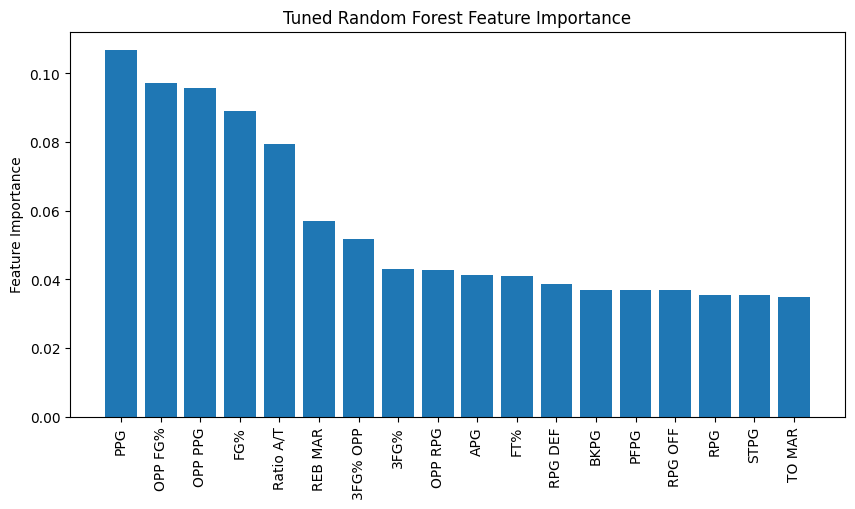

<Figure size 640x480 with 0 Axes>

In [110]:
feature_importance = rf_model.feature_importances_
feature_names = x.columns

sort_indices = np.argsort(feature_importance)[::-1]
plt.figure(figsize=(10,5))
plt.bar(range(len(feature_importance)), feature_importance[sort_indices], align="center")
plt.xticks(range(len(feature_importance)), np.array(feature_names)[sort_indices], rotation=90)
plt.ylabel("Feature Importance")
plt.title("Tuned Random Forest Feature Importance")
plt.show()
plt.savefig("Tuned_RF_Feature_importance.png", dpi=300)

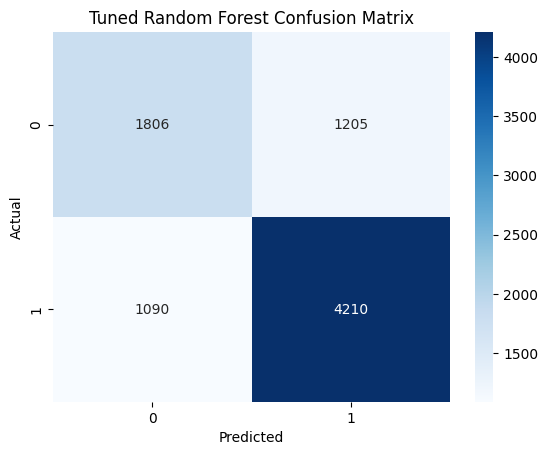

<Figure size 640x480 with 0 Axes>

In [111]:
sns.heatmap(
    confusion_matrix(ytest, rf_model.predict(xtest)),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()
plt.savefig("Tuned_RF_Confusion_Matrix.png", dpi=300)

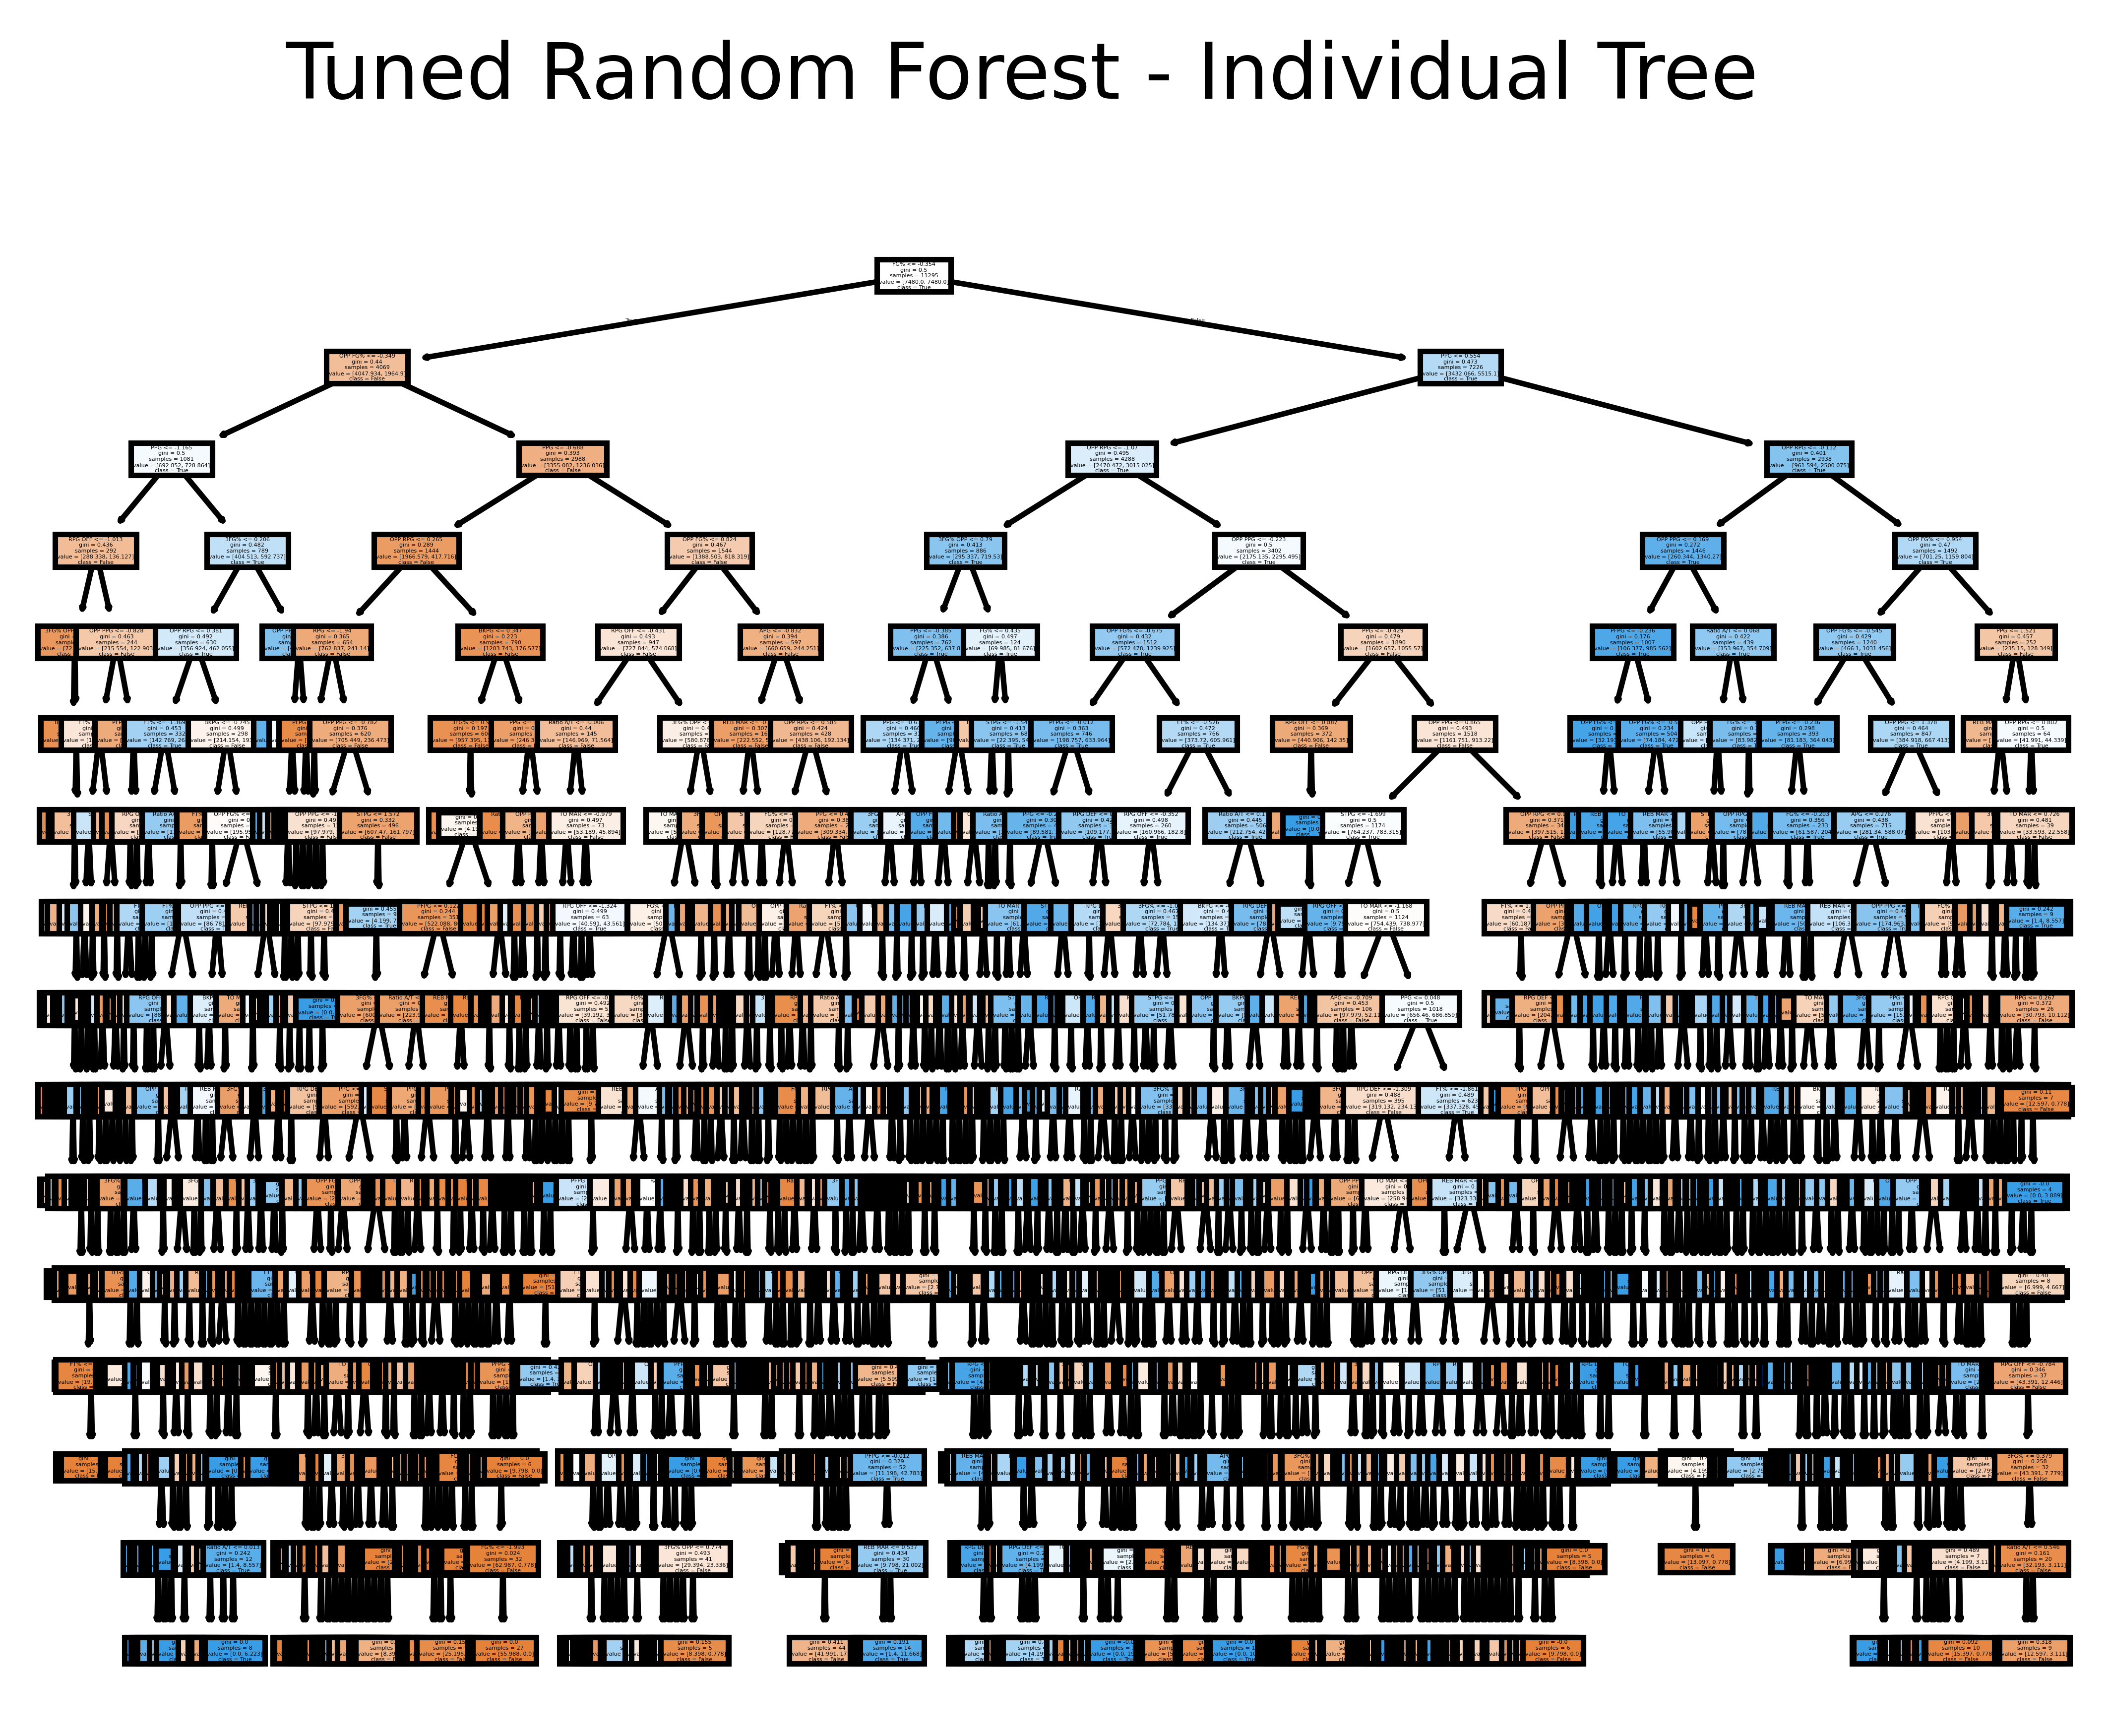

In [112]:
fn = x.columns
cn = label_encoder.classes_.astype(str)
fig, axes = plt.subplots(nrows = 1,ncols = 1, dpi=800)
tree.plot_tree(rf_model.estimators_[0],
               feature_names = fn, 
               class_names=cn,
               filled = True);
fig.suptitle("Tuned Random Forest - Individual Tree", fontsize=14)
fig.savefig('Tuned_rf_individualtree.png')

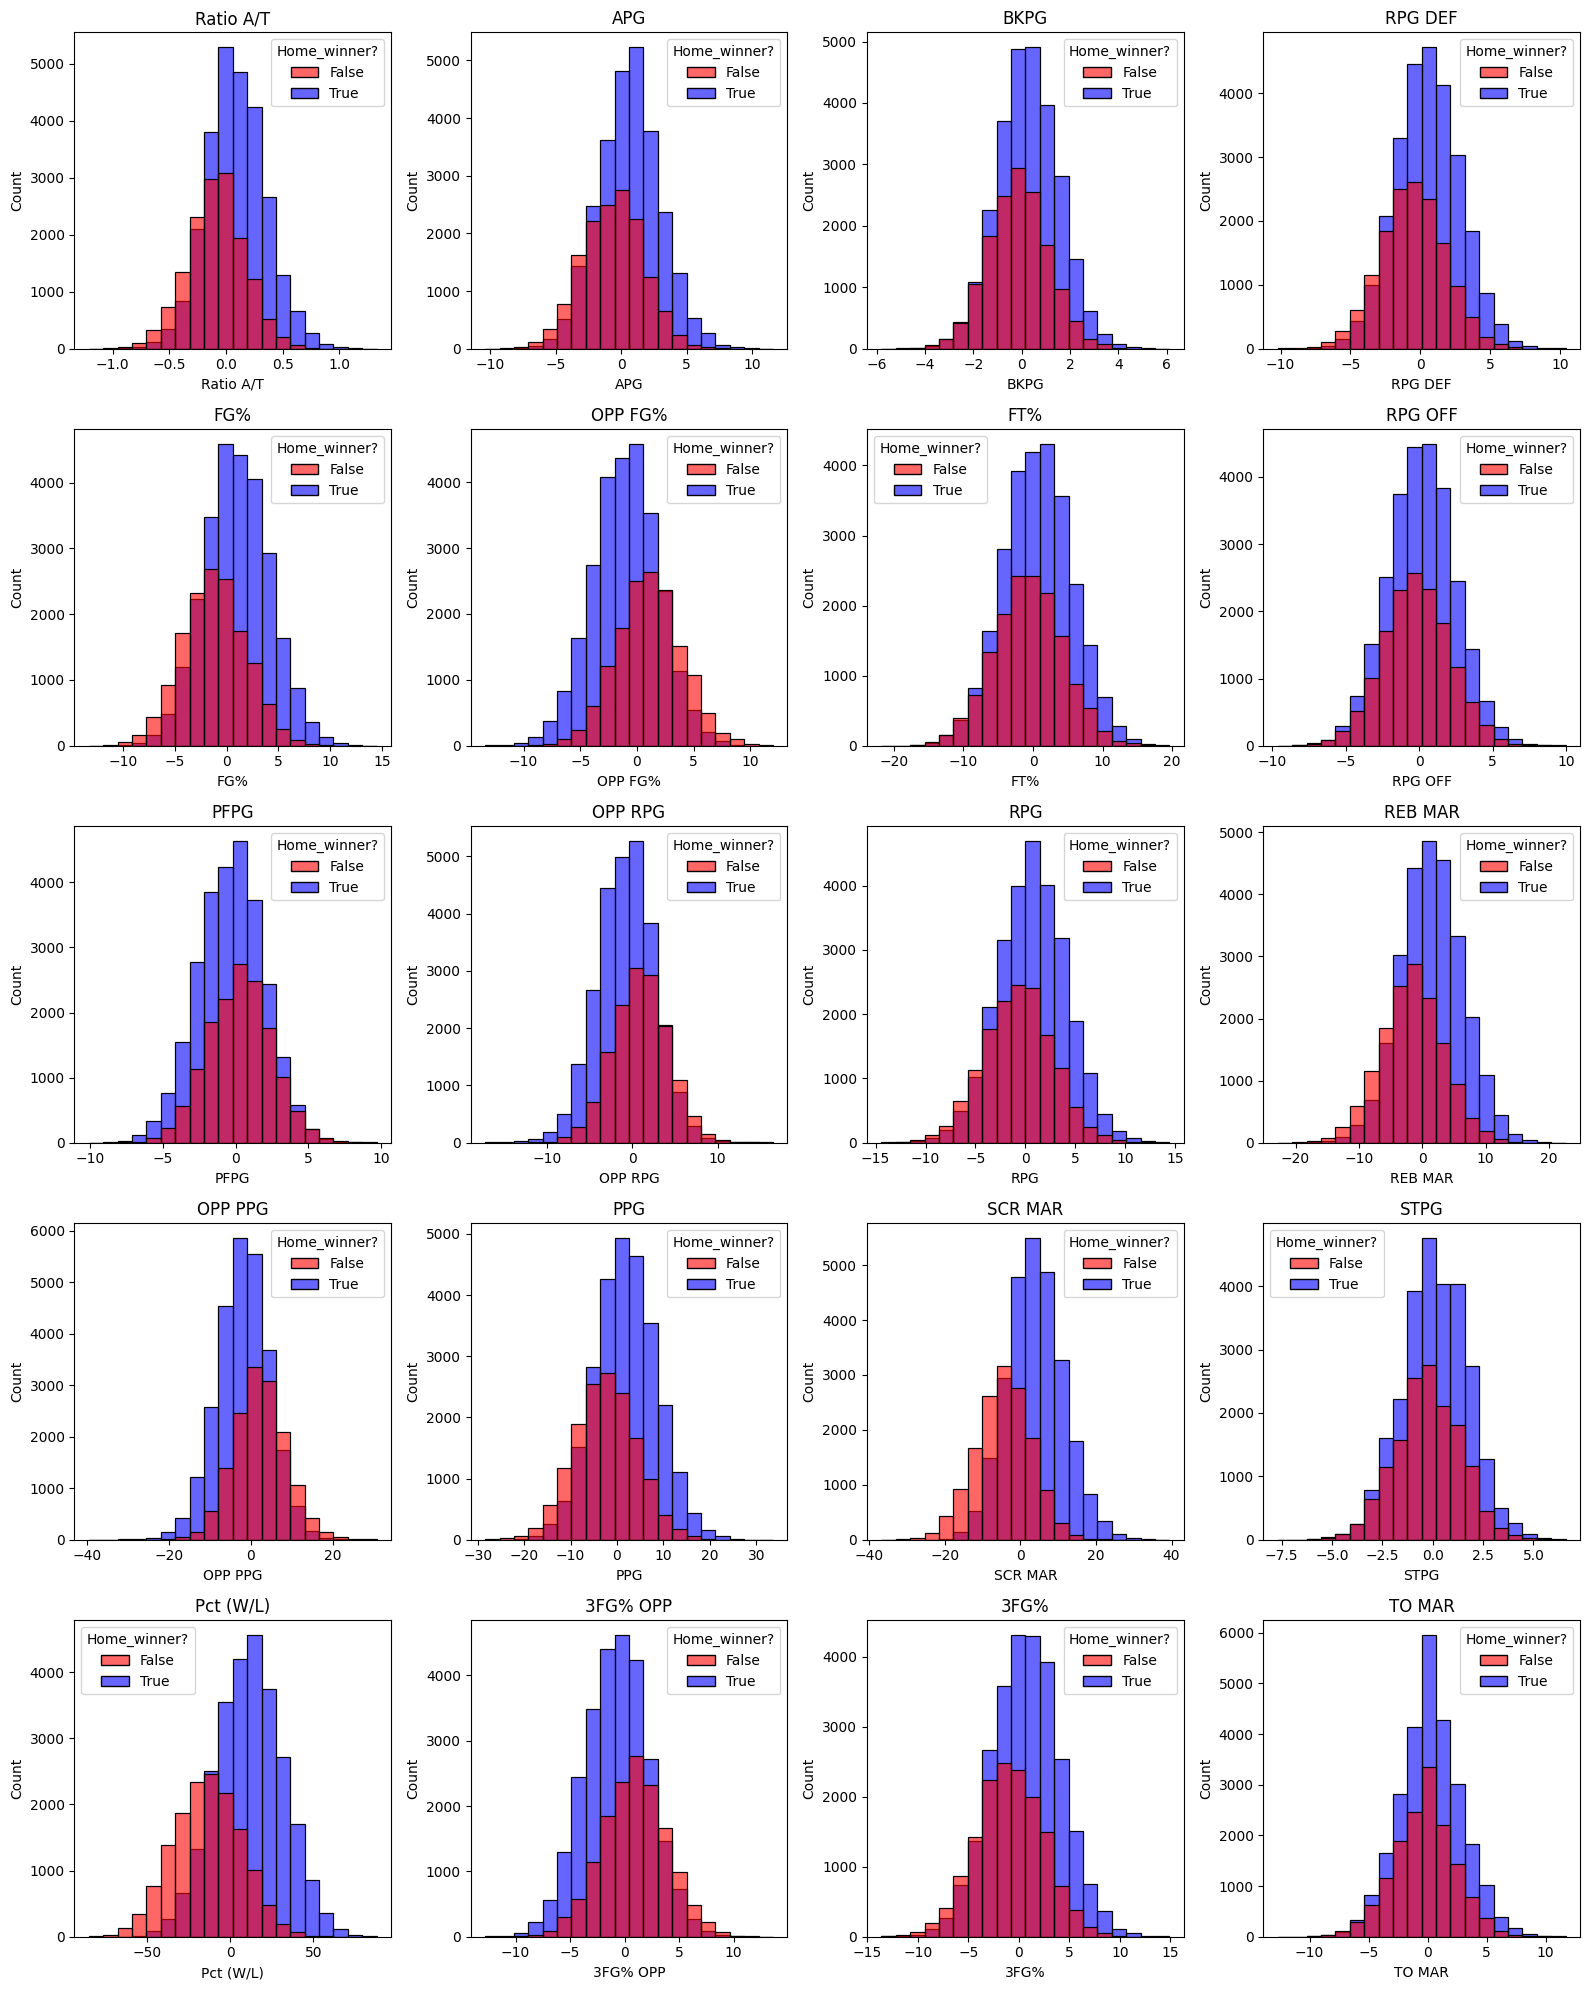

In [13]:
game_data = pd.read_csv("/home/iolson26/Math stuff/Games_Spreadsheets/Compiled DATA REAL.csv")
game_data = game_data.drop(columns=["Date", "Year", "Home_team", "Away_Team", "Away_Winner?"
                                   ])

features = [col for col in game_data.columns if col != 'Home_winner?']

# Determine subplot grid size
n_cols = 4
n_rows = (len(features) + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*4))
axes = axes.flatten()  # flatten to 1D for easy iteration

for i, feature in enumerate(features):
    sns.histplot(
        data=game_data,
        x=feature,
        hue='Home_winner?',
        bins=20,
        kde=False,
        palette={0:'red', 1:'blue'},
        alpha=0.6,
        ax=axes[i]
    )
    axes[i].set_title(feature)
    
plt.tight_layout()
plt.show()
fig.savefig("all_features_histograms.png", dpi=300)